# ETTS Model Comparison: S4 vs LMU Across Data Fractions

This notebook compares S4 and LMU models trained on different fractions of the ETTS dataset.

**Objectives:**
- Compare S4 vs LMU performance across different ETT datasets
- Analyze data efficiency (which model learns better with less data)
- Visualize learning curves
- Identify the best model/fraction combination for each dataset

**Datasets:** ETTh1, ETTh2, ETTm1, ETTm2
**Fractions tested:** 10%, 25%, 50%, 75%


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Imports successful")

Imports successful


## 2. Select Dataset to Compare

Choose which ETT dataset to analyze. Available options:
- `etth1` - ETT Hourly dataset 1
- `etth2` - ETT Hourly dataset 2
- `ettm1` - ETT 15-minute dataset 1
- `ettm2` - ETT 15-minute dataset 2


In [2]:
# ============================================
# CONFIGURATION - Change dataset here
# ============================================
dataset = "etth1"  # Options: 'etth1', 'etth2', 'ettm1', 'ettm2'

# Standard configuration
base_dir = "./runs"
models = ['s4', 'lmu']
fractions = [0.1, 0.25, 0.5, 0.75, 1.0]

print(f"Selected dataset: {dataset.upper()}")
print(f"Models: {', '.join([m.upper() for m in models])}")
print(f"Fractions: {', '.join([f'{int(f*100)}%' for f in fractions])}")


Selected dataset: ETTH1
Models: S4, LMU
Fractions: 10%, 25%, 50%, 75%, 100%


## 3. Load ETTS Experiment Results

Load all S4 and LMU results for the selected dataset across different data fractions.


In [3]:
print("="*60)
print(f"LOADING {dataset.upper()} EXPERIMENT RESULTS")
print("="*60)
print()

# Import necessary modules for evaluation
from src.notebooks.etts.etts_task import ETTSTask
from src.notebooks.etts.etts_eval import evaluate_best_model
from src.utils.block_configs import create_lmu_block_cfg_ctor, create_s4_block_cfg_ctor
import etts_config

def load_etts_experiments(base_dir, models, fractions, dataset):
    """Load ETTS experiments and evaluate on test set using configs from etts_config."""
    base_path = Path(base_dir)
    all_results = {}

    # Initialize task
    task = ETTSTask()

    for model in models:
        all_results[model] = {}

        for frac in fractions:
            frac_pct = int(frac * 100)

            # Load the appropriate config from etts_config
            config_name = f"{dataset}_config_{model}"
            if not hasattr(etts_config, config_name):
                print(f"Config not found: {config_name}")
                all_results[model][frac] = {}
                continue

            args = dict(getattr(etts_config, config_name))

            # Get dataset type from config
            etts_type = args['data_loader_kwargs']['which']

            # Update args for this fraction
            args["fraction"] = frac
            if frac_pct < 100:
                args["save_dir"] = f"./runs/etts_{model}_task_{etts_type.lower()}_frac{frac_pct}"
            else:
                args["save_dir"] = f"./runs/etts_{model}_task_{etts_type.lower()}"

            run_dir = Path(args["save_dir"])
            checkpoint_path = run_dir / "best.pt"

            if run_dir.exists() and checkpoint_path.exists():
                print(f"Loading {model.upper()} @ {frac*100:.0f}%: {run_dir.name}")
                print(f"  Checkpoint: {checkpoint_path}")
                try:
                    # Set device
                    args["device"] = torch.device("cpu")

                    # Create block config constructor
                    if model == "lmu":
                        args["block_cfg_ctor"] = create_lmu_block_cfg_ctor(
                            dropout=args["dropout"],
                            mlp_ratio=args["mlp_ratio"],
                            droppath_final=args["droppath_final"],
                            layerscale_init=args["layerscale_init"],
                            residual_gain=args["residual_gain"],
                            pool=args["pool"],
                        )
                    else:  # s4
                        args["block_cfg_ctor"] = create_s4_block_cfg_ctor(
                            dropout=args["dropout"],
                            mlp_ratio=args["mlp_ratio"],
                            droppath_final=args["droppath_final"],
                            layerscale_init=args["layerscale_init"],
                            residual_gain=args["residual_gain"],
                            pool=args["pool"],
                            d_state=args.get("d_state", 64),
                            mode=args.get("mode", "s4d"),
                            bidirectional=args.get("bidirectional", False),
                        )

                    # Evaluate on test set
                    print(f"  Evaluating on test set...")
                    test_mae, test_mse, test_rmse = evaluate_best_model(
                        args=args,
                        task=task,
                        best_model_path=str(checkpoint_path)
                    )


                    # Load checkpoint for history
                    checkpoint = torch.load(checkpoint_path, map_location='cpu')
                    history = checkpoint.get('history', {})

                    results = {
                        'run_dir': str(run_dir),
                        'history': history,
                        'checkpoint_path': str(checkpoint_path),
                        'best_test_mse': test_mse,
                        'best_test_mae': test_mae,
                        'best_test_rmse': test_rmse,
                        'epochs_trained': len(history.get('val_loss', [])) if history.get('val_loss') else 0,
                    }

                    # Keep validation metrics for learning curves
                    if 'val_loss' in history and history['val_loss']:
                        results['best_val_loss'] = min(history['val_loss'])
                        results['final_val_loss'] = history['val_loss'][-1]

                    if 'val_mae' in history and history['val_mae']:
                        results['best_val_mae'] = min(history['val_mae'])
                        results['final_val_mae'] = history['val_mae'][-1]

                    if 'train_loss' in history and history['train_loss']:
                        results['final_train_loss'] = history['train_loss'][-1]

                    all_results[model][frac] = results
                    print(f"  Test MAE: {test_mae:.6f}, Test MSE: {test_mse:.6f}")
                    print(f"  Stored - MAE: {results['best_test_mae']:.6f}, MSE: {results['best_test_mse']:.6f}, RMSE: {results['best_test_rmse']:.6f}")


                except Exception as e:
                    print(f"Error loading/evaluating: {e}")
                    import traceback
                    traceback.print_exc()
                    all_results[model][frac] = {}
            else:
                print(f"Run not found: {run_dir}")
                all_results[model][frac] = {}

    return all_results

# Load results
all_results = load_etts_experiments(base_dir, models, fractions, dataset)

print()
print("="*60)
print("LOADING COMPLETE")
print("="*60)

# Quick summary
for model in models:
    n_loaded = sum(1 for results in all_results[model].values() if results)
    print(f"{model.upper()}: Loaded {n_loaded}/{len(fractions)} experiments")

LOADING ETTH1 EXPERIMENT RESULTS



CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


Loading S4 @ 10%: etts_s4_task_etth1_frac10
  Checkpoint: runs/etts_s4_task_etth1_frac10/best.pt
  Best Val MAE: 0.355950, Best Val Loss: 0.180718
Loading S4 @ 25%: etts_s4_task_etth1_frac25
  Checkpoint: runs/etts_s4_task_etth1_frac25/best.pt
  Best Val MAE: 0.351749, Best Val Loss: 0.185948
Loading S4 @ 50%: etts_s4_task_etth1_frac50
  Checkpoint: runs/etts_s4_task_etth1_frac50/best.pt
  Best Val MAE: 0.375267, Best Val Loss: 0.206978
Loading S4 @ 75%: etts_s4_task_etth1_frac75
  Checkpoint: runs/etts_s4_task_etth1_frac75/best.pt
  Best Val MAE: 0.194401, Best Val Loss: 0.064132
Loading S4 @ 100%: etts_s4_task_etth1
  Checkpoint: runs/etts_s4_task_etth1/best.pt
  Best Val MAE: 0.213164, Best Val Loss: 0.072793
Loading LMU @ 10%: etts_lmu_task_etth1_frac10
  Checkpoint: runs/etts_lmu_task_etth1_frac10/best.pt
  Best Val MAE: 0.287049, Best Val Loss: 0.128782
Loading LMU @ 25%: etts_lmu_task_etth1_frac25
  Checkpoint: runs/etts_lmu_task_etth1_frac25/best.pt
  Best Val MAE: 0.342917, Be

## 4. EXPERIMENT COMPARISON TABLE


In [ ]:
from src.eval.compare import create_comparison_table

print("="*60)
print(f"EXPERIMENT COMPARISON TABLE - {dataset.upper()}")
print("="*60)
print()

comparison_df = create_comparison_table(
    all_results,
    metrics=['best_test_mae', 'best_test_mse', 'best_test_rmse', 'epochs_trained']
)

print(comparison_df.to_string(index=False))
print()

# Save to CSV
csv_path = Path(f"./comparison_results_{dataset}.csv")
comparison_df.to_csv(csv_path, index=False)
print(f"Saved to: {csv_path}")


## 5. Validation Loss Learning Curves

Compare how validation loss evolves during training for different data fractions.

**Note:** These curves show validation metrics during training (used for model selection). Final performance comparisons use test set metrics.


In [ ]:
from src.eval.compare import plot_learning_curves

plot_learning_curves(
    all_results,
    metric='val_loss',
    title_suffix=f' - {dataset.upper()} Dataset',
    ylabel='Validation Loss (MSE)'
)


## 6. Validation MAE Learning Curves

Compare MAE (Mean Absolute Error) across training.


In [ ]:
plot_learning_curves(
    all_results,
    metric='val_mae',
    title_suffix=f' - {dataset.upper()} Dataset',
    ylabel='Validation MAE'
)


## 7. Best Performance Comparison

Bar chart showing best test MAE for each model and fraction.


In [ ]:
from src.eval.compare import plot_metric_comparison_bar

plot_metric_comparison_bar(
    all_results,
    metric_key='best_test_mae',
    title=f'Best Test MAE: S4 vs LMU - {dataset.upper()}',
    ylabel='Best MAE',
)


## 8. Data Efficiency Analysis

Which model learns better with limited data?


In [ ]:
from src.eval.compare import plot_data_efficiency

plot_data_efficiency(
    all_results,
    metric_key='best_test_mae',
    ylabel='Best Test MAE'
)


## 9. Winner Analysis

Which model performs best at each data fraction?


In [ ]:
print("="*60)
print(f"WINNER ANALYSIS - {dataset.upper()}")
print("="*60)
print()

for frac in fractions:
    print(f"\n📊 Data Fraction: {int(frac*100)}%")
    print("-" * 40)

    best_model = None
    best_mae = float('inf')

    for model in models:
        results = all_results[model].get(frac, {})
        if results and 'best_test_mae' in results:
            mae = results['best_test_mae']
            print(f"  {model.upper():3s}: {mae:.4f}")

            if mae < best_mae:
                best_mae = mae
                best_model = model

    if best_model:
        print(f"\n✅ Winner: {best_model.upper()} (MAE: {best_mae:.4f})")

        # Calculate margin
        for model in models:
            if model != best_model:
                other_results = all_results[model].get(frac, {})
                if other_results and 'best_test_mae' in other_results:
                    other_mae = other_results['best_test_mae']
                    improvement = ((other_mae - best_mae) / other_mae) * 100
                    print(f"  Beats {model.upper()} by {improvement:.1f}%")


## 11. Compare All Datasets (Optional)

Run this cell to compare performance across all ETT datasets at once.


In [4]:
import pandas as pd

datasets = ['etth1', 'etth2', 'ettm1', 'ettm2']
all_datasets_results = {}

print("="*60)
print("LOADING ALL DATASETS")
print("="*60)
print()

for ds in datasets:
    print(f"\nLoading {ds.upper()}...")
    all_datasets_results[ds] = load_etts_experiments(base_dir, models, fractions, ds)

print("\n" + "="*60)
print("SUMMARY ACROSS ALL DATASETS")
print("="*60)
print()

# Create comprehensive comparison
summary_rows = []

for ds in datasets:
    for model in models:
        for frac in fractions:
            results = all_datasets_results[ds][model].get(frac, {})
            if results and 'best_test_mae' in results:
                summary_rows.append({
                    'Dataset': ds.upper(),
                    'Model': model.upper(),
                    'Fraction': f"{int(frac*100)}%",
                    'Best Test MAE': f"{results['best_test_mae']:.4f}",
                    'Best Test MSE': f"{results.get('best_test_mse', 'N/A'):.4f}" if isinstance(results.get('best_test_mse'), (int, float)) else 'N/A',
                    'Best Test RMSE': f"{results.get('best_test_rmse', 'N/A'):.4f}" if isinstance(results.get('best_test_rmse'), (int, float)) else 'N/A',
                    'Epochs': results.get('epochs_trained', 'N/A')
                })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print()

# Save comprehensive results
csv_path = Path("./comparison_results_all_datasets.csv")
summary_df.to_csv(csv_path, index=False)
print(f"\nSaved to: {csv_path}")


LOADING ALL DATASETS


Loading ETTH1...
Loading S4 @ 10%: etts_s4_task_etth1_frac10
  Checkpoint: runs/etts_s4_task_etth1_frac10/best.pt
  Best Val MAE: 0.355950, Best Val Loss: 0.180718
Loading S4 @ 25%: etts_s4_task_etth1_frac25
  Checkpoint: runs/etts_s4_task_etth1_frac25/best.pt
  Best Val MAE: 0.351749, Best Val Loss: 0.185948
Loading S4 @ 50%: etts_s4_task_etth1_frac50
  Checkpoint: runs/etts_s4_task_etth1_frac50/best.pt
  Best Val MAE: 0.375267, Best Val Loss: 0.206978
Loading S4 @ 75%: etts_s4_task_etth1_frac75
  Checkpoint: runs/etts_s4_task_etth1_frac75/best.pt
  Best Val MAE: 0.194401, Best Val Loss: 0.064132
Loading S4 @ 100%: etts_s4_task_etth1
  Checkpoint: runs/etts_s4_task_etth1/best.pt
  Best Val MAE: 0.213164, Best Val Loss: 0.072793
Loading LMU @ 10%: etts_lmu_task_etth1_frac10
  Checkpoint: runs/etts_lmu_task_etth1_frac10/best.pt
  Best Val MAE: 0.287049, Best Val Loss: 0.128782
Loading LMU @ 25%: etts_lmu_task_etth1_frac25
  Checkpoint: runs/etts_lmu_task_etth1_fra

## 12. Cross-Dataset Visualization

Visualize model performance across all datasets with heatmaps.


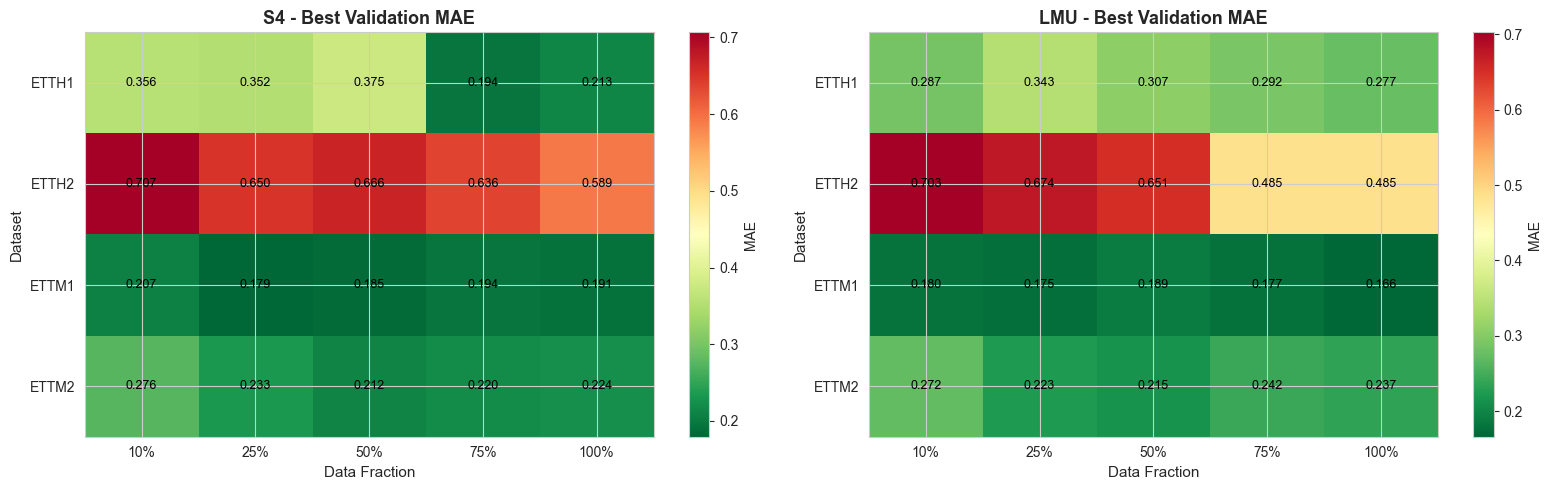

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, model in enumerate(models):
    ax = axes[idx]

    # Prepare data matrix
    data = []
    for ds in datasets:
        row = []
        for frac in fractions:
            results = all_datasets_results[ds][model].get(frac, {})
            mae = results.get('best_test_mae', np.nan)
            row.append(mae)
        data.append(row)

    # Plot heatmap
    im = ax.imshow(data, aspect='auto', cmap='RdYlGn_r')

    # Set ticks and labels
    ax.set_xticks(range(len(fractions)))
    ax.set_xticklabels([f"{int(f*100)}%" for f in fractions])
    ax.set_yticks(range(len(datasets)))
    ax.set_yticklabels([ds.upper() for ds in datasets])

    # Add values to cells
    for i in range(len(datasets)):
        for j in range(len(fractions)):
            if not np.isnan(data[i][j]):
                text = ax.text(j, i, f'{data[i][j]:.3f}',
                             ha="center", va="center", color="black", fontsize=9)

    ax.set_xlabel('Data Fraction', fontsize=11)
    ax.set_ylabel('Dataset', fontsize=11)
    ax.set_title(f'{model.upper()} - Best Test MAE', fontsize=13, fontweight='bold')

    # Colorbar
    plt.colorbar(im, ax=ax, label='MAE')

plt.tight_layout()
plt.show()
